NAME: KHUSHBOO YADAV

ROLL NO: 23102A0062

CLASS/DIV: CMPN A

### Experiment Overview

In this experiment, customer transaction data from an online retail company is analyzed to understand different types of customers and identify high-value customers. The task is to preprocess the transaction data, create customer-level features such as Recency, Frequency and Monetary Value (RFM), and perform customer segmentation using K-Means and Hierarchical Clustering.

The clusters are evaluated using the Elbow Method and Silhouette Score, and PCA is used to visualize the customer segments. After identifying the high-value customer segment, Random Forest and SVM models are trained to predict whether a customer belongs to this segment. Finally, the models are evaluated using classification metrics, feature importance is analyzed, and suitable marketing strategies are suggested for each customer segment.

GITHUB LINK: https://github.com/khushboo375/23102A0062_RProgramming

In [1]:
!pip install -q openpyxl xlrd plotly

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from scipy.cluster.hierarchy import dendrogram, linkage

import plotly.express as px
import plotly.graph_objects as go

from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

zip_path = "/content/online_retail.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/online_retail")

print("Dataset downloaded successfully.")

for root, dirs, files_list in os.walk("/content/online_retail"):
    for file in files_list:
        print(os.path.join(root, file))

Dataset downloaded successfully.
/content/online_retail/Online Retail.xlsx


In [4]:
import glob

files_found = glob.glob("/content/online_retail/**/*", recursive=True)

print("Files found:")
for f in files_found:
    print(f)

Files found:
/content/online_retail/Online Retail.xlsx


In [5]:
excel_file = [f for f in files_found if f.endswith(".xlsx")][0]

df = pd.read_excel(excel_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

Shape of dataset:
(541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

First 5 records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Percentage": (missing.values / len(df)) * 100
})

missing_df.sort_values("Missing Values", ascending=False)

,Column,Missing Values,Percentage
6,CustomerID,135080,24.926694
2,Description,1454,0.268311
1,StockCode,0,0.000000
0,InvoiceNo,0,0.000000
3,Quantity,0,0.000000
4,InvoiceDate,0,0.000000
5,UnitPrice,0,0.000000
7,Country,0,0.000000


In [9]:
print("Before removing missing Customer IDs:", df.shape)

df = df.dropna(subset=["CustomerID"])

print("After removing missing Customer IDs:", df.shape)

Before removing missing Customer IDs: (541909, 8)
After removing missing Customer IDs: (406829, 8)


In [10]:
df["CustomerID"] = df["CustomerID"].astype(int)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


In [11]:
print("Number of cancelled transactions:",
      df["InvoiceNo"].astype(str).str.startswith("C").sum())

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Dataset after removing cancellations:", df.shape)

Number of cancelled transactions: 8905
Dataset after removing cancellations: (397924, 8)


In [12]:
print("Negative/zero quantities:",
      (df["Quantity"] <= 0).sum())

print("Negative/zero prices:",
      (df["UnitPrice"] <= 0).sum())

Negative/zero quantities: 0
Negative/zero prices: 40


In [13]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (397884, 8)


In [14]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].describe()

,Quantity,UnitPrice,TotalAmount
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [15]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]

print("Before outlier treatment:", df.shape)

df = remove_outliers_iqr(df, "Quantity")
df = remove_outliers_iqr(df, "UnitPrice")
df = remove_outliers_iqr(df, "TotalAmount")

print("After outlier treatment:", df.shape)

Before outlier treatment: (397884, 9)
After outlier treatment: (324716, 9)


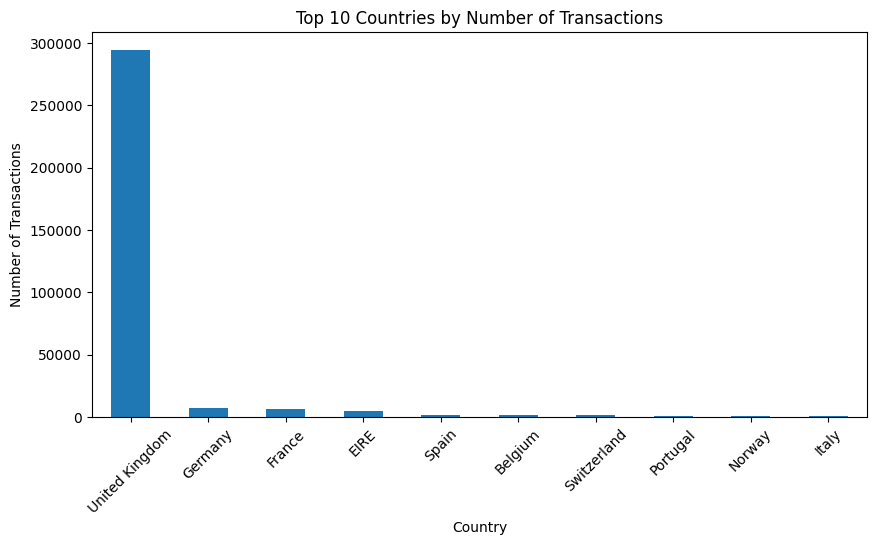

In [16]:
country_counts = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

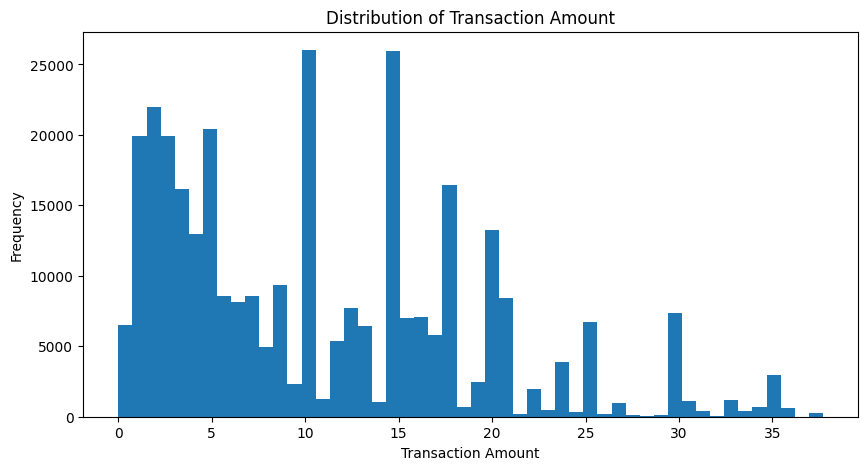

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df["TotalAmount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

In [18]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [19]:
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    AverageTransactionValue=("TotalAmount", "mean")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue
0,12347,2,7,2783.37,1701,17.957226
1,12348,249,3,90.20,140,15.033333
2,12349,19,1,939.75,511,16.486842
3,12350,310,1,294.40,196,18.400000
4,12352,36,7,1130.94,500,17.135455


In [20]:
rfm["PurchaseFrequency"] = (
    rfm["Frequency"] /
    ((df["InvoiceDate"].max() - df["InvoiceDate"].min()).days / 30)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency
0,12347,2,7,2783.37,1701,17.957226,0.563003
1,12348,249,3,90.20,140,15.033333,0.241287
2,12349,19,1,939.75,511,16.486842,0.080429
3,12350,310,1,294.40,196,18.400000,0.080429
4,12352,36,7,1130.94,500,17.135455,0.563003


In [21]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4146.0,15296.229378,1718.519565,12347.000000,13819.500000,15290.500000,16775.750000,18287.000000
Recency,4146.0,93.181380,100.015984,1.000000,18.000000,51.000000,145.000000,374.000000
Frequency,4146.0,3.918234,6.813902,1.000000,1.000000,2.000000,4.000000,193.000000
Monetary,4146.0,850.105138,1767.635549,1.700000,173.970000,405.625000,964.527500,70409.910000
TotalQuantity,4146.0,553.800531,1144.629218,1.000000,104.000000,262.000000,639.750000,45058.000000
AverageTransactionValue,4146.0,13.707703,5.891005,0.747143,8.647140,15.231120,17.448509,37.500000
PurchaseFrequency,4146.0,0.315139,0.548035,0.080429,0.080429,0.160858,0.321716,15.522788


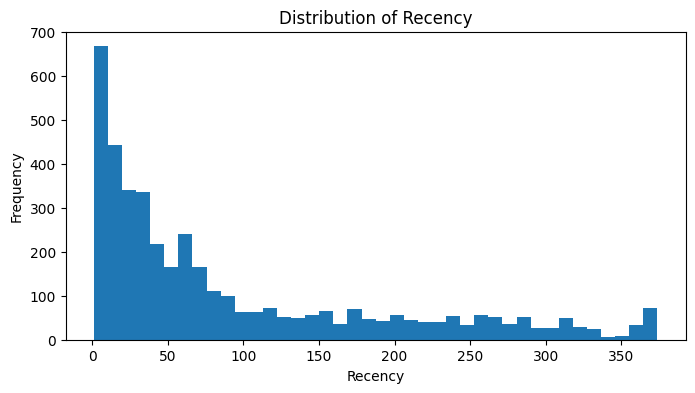

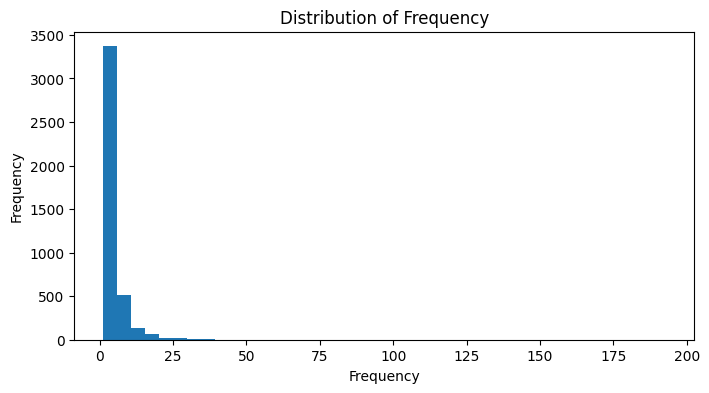

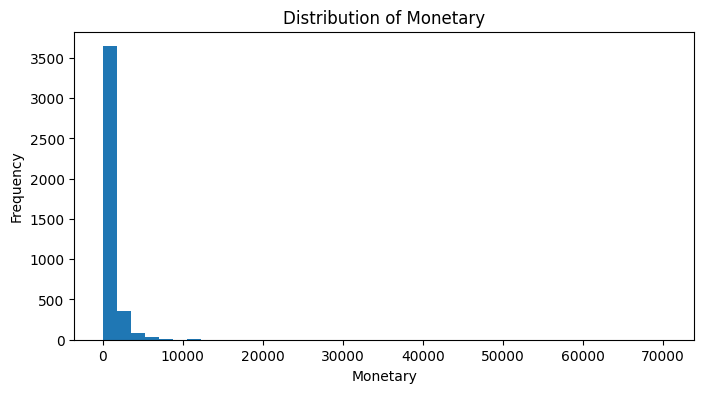

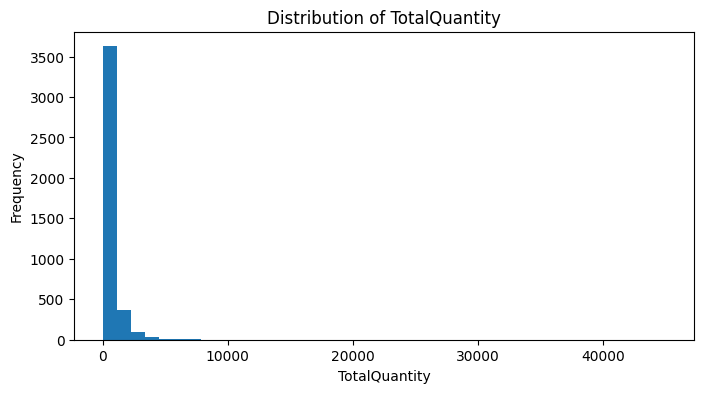

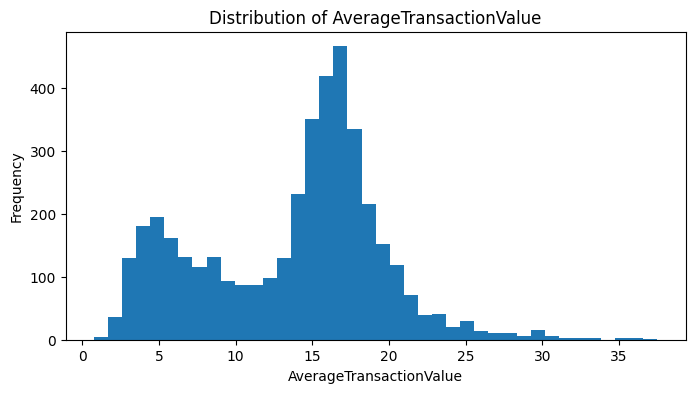

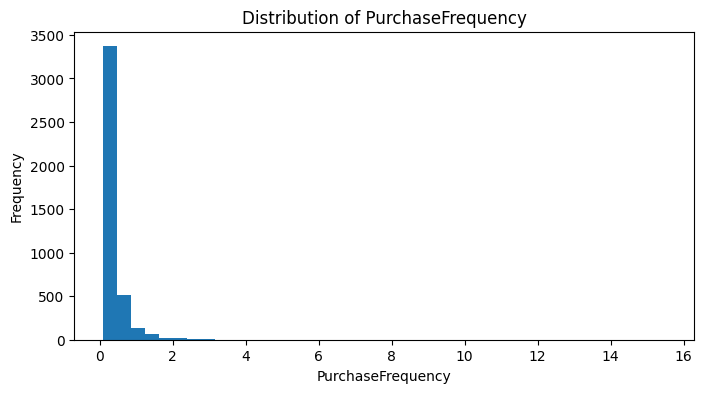

In [22]:
features_to_plot = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageTransactionValue",
    "PurchaseFrequency"
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    plt.hist(rfm[feature], bins=40)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [23]:
rfm_log = rfm.copy()

for feature in features_to_plot:
    rfm_log[feature] = np.log1p(rfm_log[feature])

rfm_log.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency
0,12347,1.098612,2.079442,7.931777,7.439559,2.942185,0.446609
1,12348,5.521461,1.386294,4.513055,4.948760,2.774670,0.216149
2,12349,2.995732,0.693147,6.846677,6.238325,2.861449,0.077358
3,12350,5.739793,0.693147,5.688330,5.283204,2.965273,0.077358
4,12352,3.610918,2.079442,7.031688,6.216606,2.897869,0.446609


In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    rfm_log[features_to_plot]
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features_to_plot
)

X_scaled.head()

,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency
0,-2.066004,1.181234,1.540394,1.457160,0.714953,0.908761
1,1.258173,0.119176,-1.183731,-0.445322,0.383023,-0.099866
2,-0.640144,-0.942883,0.675759,0.539653,0.554974,-0.707293
3,1.422269,-0.942883,-0.247241,-0.189872,0.760701,-0.707293
4,-0.177776,1.181234,0.823180,0.523064,0.627140,0.908761


In [25]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

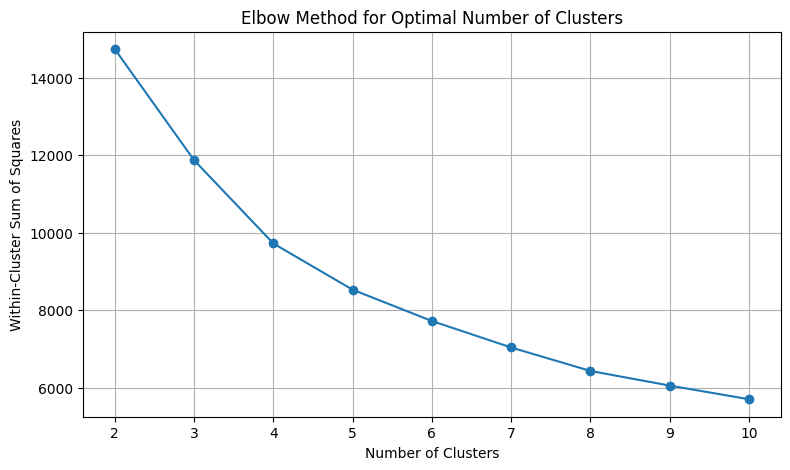

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")

plt.xticks(K)
plt.grid(True)

plt.show()

In [27]:
optimal_k = 4

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 4


In [28]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency,Cluster
0,12347,2,7,2783.37,1701,17.957226,0.563003,3
1,12348,249,3,90.20,140,15.033333,0.241287,2
2,12349,19,1,939.75,511,16.486842,0.080429,1
3,12350,310,1,294.40,196,18.400000,0.080429,2
4,12352,36,7,1130.94,500,17.135455,0.563003,1


In [29]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0     719
1    1430
2    1519
3     478
Name: count, dtype: int64


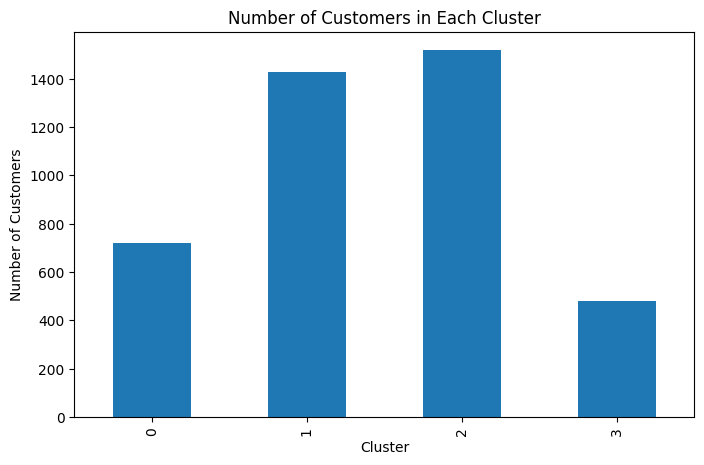

In [30]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [31]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    rfm["Cluster"]
)

print("K-Means Silhouette Score:",
      round(kmeans_silhouette, 4))

K-Means Silhouette Score: 0.2922


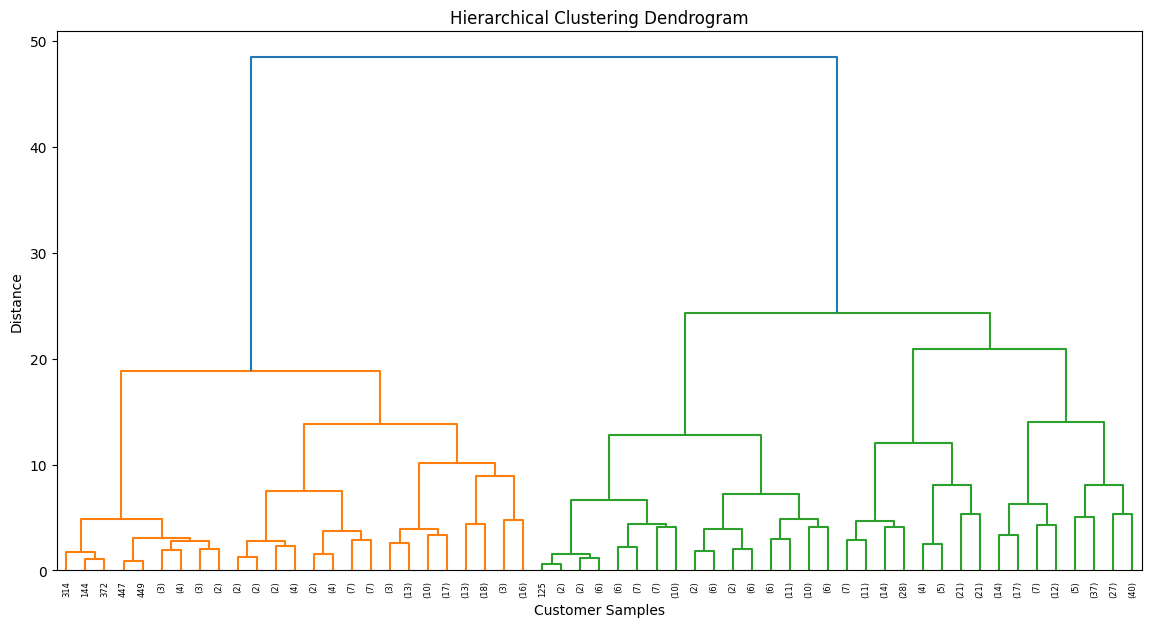

In [32]:
# Sample customers to make dendrogram computationally manageable
sample_size = min(500, len(X_scaled))

sample_indices = np.random.RandomState(42).choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled.iloc[sample_indices]

linked = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Samples")
plt.ylabel("Distance")

plt.show()

In [33]:
hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

rfm["HierarchicalCluster"] = hierarchical_labels

rfm.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency,Cluster,HierarchicalCluster
0,12347,2,7,2783.37,1701,17.957226,0.563003,3,1
1,12348,249,3,90.20,140,15.033333,0.241287,2,2
2,12349,19,1,939.75,511,16.486842,0.080429,1,0
3,12350,310,1,294.40,196,18.400000,0.080429,2,0
4,12352,36,7,1130.94,500,17.135455,0.563003,1,1


In [34]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

Hierarchical Clustering Silhouette Score: 0.2768


In [35]:
comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

comparison

,Method,Silhouette Score
0,K-Means,0.292177
1,Hierarchical Clustering,0.276770


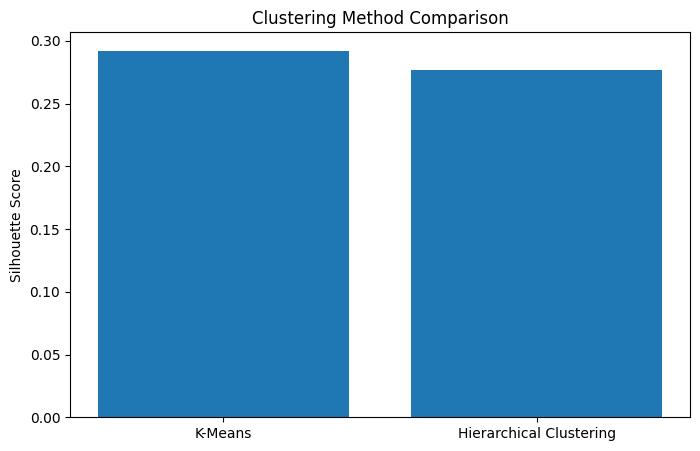

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Method"],
    comparison["Silhouette Score"]
)

plt.title("Clustering Method Comparison")
plt.ylabel("Silhouette Score")

plt.show()

In [37]:
cluster_profile = rfm.groupby("Cluster")[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "TotalQuantity",
        "AverageTransactionValue",
        "PurchaseFrequency"
    ]
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency
Cluster,,,,,,
0,110.51,1.81,257.32,173.49,5.03,0.15
1,47.02,4.01,995.80,653.97,14.59,0.32
2,153.19,1.35,216.69,135.91,17.02,0.11
3,14.53,14.96,3318.79,2154.17,13.58,1.20


In [38]:
cluster_profile["CustomerCount"] = (
    rfm.groupby("Cluster").size()
)

cluster_profile

,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency,CustomerCount
Cluster,,,,,,,
0,110.51,1.81,257.32,173.49,5.03,0.15,719
1,47.02,4.01,995.80,653.97,14.59,0.32,1430
2,153.19,1.35,216.69,135.91,17.02,0.11,1519
3,14.53,14.96,3318.79,2154.17,13.58,1.20,478


In [39]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

pca_df.head()

,PC1,PC2,Cluster
0,3.119806,0.478411,3
1,-1.181870,0.457484,2
2,0.022652,0.585451,1
3,-1.464074,1.041405,2
4,1.689894,0.624225,1


In [40]:
print(
    "Explained variance by PC1:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "Explained variance by PC2:",
    round(pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

print(
    "Total explained variance:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Explained variance by PC1: 62.69 %
Explained variance by PC2: 17.06 %
Total explained variance: 79.75 %


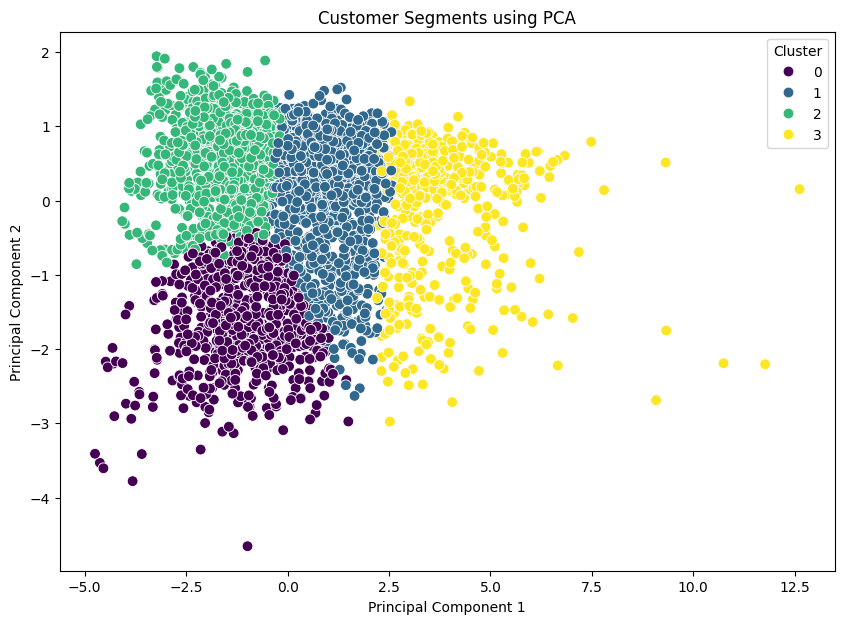

In [41]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

In [42]:
cluster_profile.sort_values(
    by=["Monetary", "Frequency"],
    ascending=False
)

,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency,CustomerCount
Cluster,,,,,,,
3,14.53,14.96,3318.79,2154.17,13.58,1.20,478
1,47.02,4.01,995.80,653.97,14.59,0.32,1430
0,110.51,1.81,257.32,173.49,5.03,0.15,719
2,153.19,1.35,216.69,135.91,17.02,0.11,1519


In [43]:
high_value_cluster = cluster_profile[
    ["Monetary", "Frequency"]
].mean(axis=1).idxmax()

print("High-value cluster:", high_value_cluster)

High-value cluster: 3


In [44]:
rfm["HighValue"] = (
    rfm["Cluster"] == high_value_cluster
).astype(int)

print(rfm["HighValue"].value_counts())

HighValue
0    3668
1     478
Name: count, dtype: int64


In [45]:
classification_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageTransactionValue",
    "PurchaseFrequency"
]

X = rfm[classification_features]
y = rfm["HighValue"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3316
Testing samples: 830


In [47]:
classification_scaler = StandardScaler()

X_train_scaled = classification_scaler.fit_transform(X_train)
X_test_scaled = classification_scaler.transform(X_test)

In [48]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [49]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42,
    class_weight="balanced"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_predictions = svm_model.predict(X_test_scaled)

svm_probabilities = svm_model.predict_proba(
    X_test_scaled
)[:, 1]

print("SVM trained successfully.")

SVM trained successfully.


In [50]:
def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

In [51]:
results = []

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        svm_predictions,
        svm_probabilities
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.993976,1.000000,0.947917,0.973262,0.999610
1,SVM,0.974699,0.820513,1.000000,0.901408,0.999617


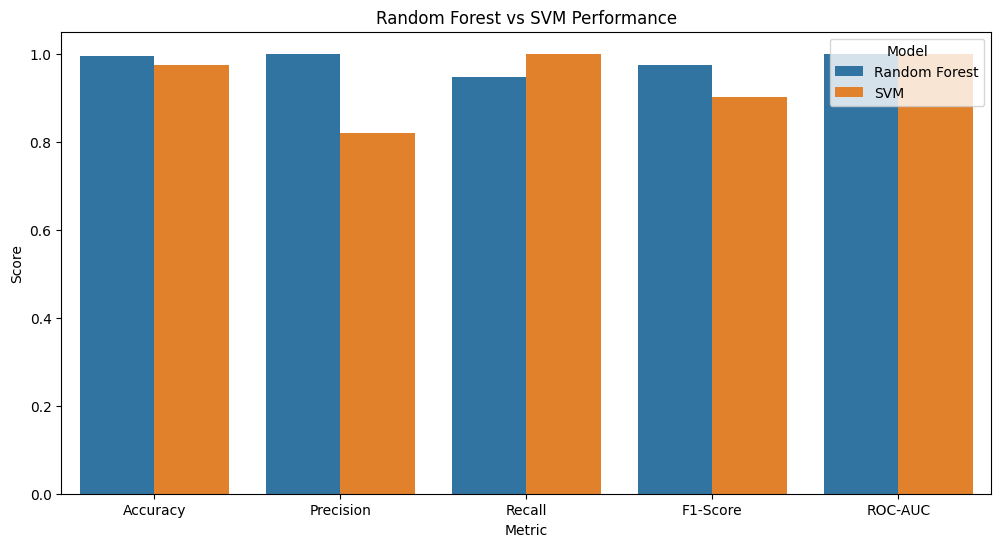

In [52]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Random Forest vs SVM Performance")
plt.ylim(0, 1.05)

plt.show()

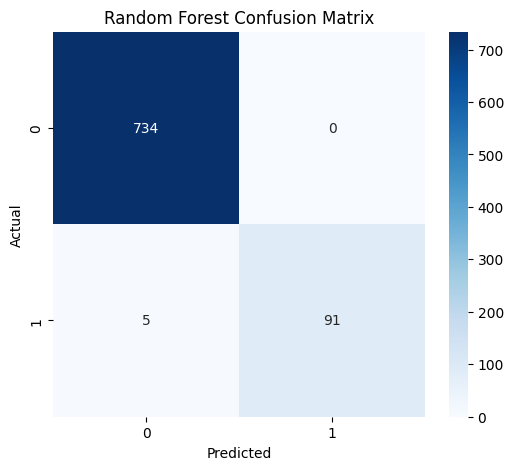

In [53]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

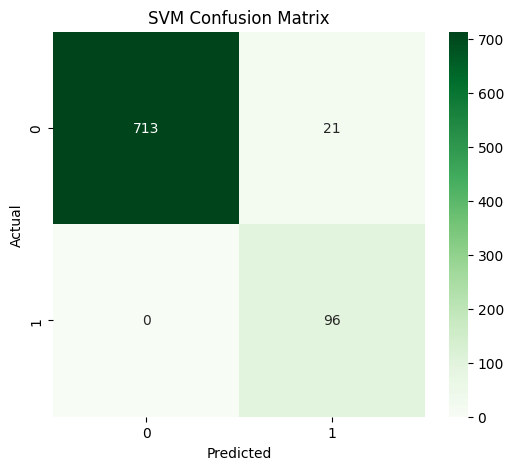

In [54]:
cm_svm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [55]:
print("Random Forest Classification Report")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Regular Customer",
            "High-Value Customer"
        ],
        zero_division=0
    )
)

Random Forest Classification Report
                     precision    recall  f1-score   support

   Regular Customer       0.99      1.00      1.00       734
High-Value Customer       1.00      0.95      0.97        96

           accuracy                           0.99       830
          macro avg       1.00      0.97      0.98       830
       weighted avg       0.99      0.99      0.99       830



In [56]:
print("SVM Classification Report")

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=[
            "Regular Customer",
            "High-Value Customer"
        ],
        zero_division=0
    )
)

SVM Classification Report
                     precision    recall  f1-score   support

   Regular Customer       1.00      0.97      0.99       734
High-Value Customer       0.82      1.00      0.90        96

           accuracy                           0.97       830
          macro avg       0.91      0.99      0.94       830
       weighted avg       0.98      0.97      0.98       830



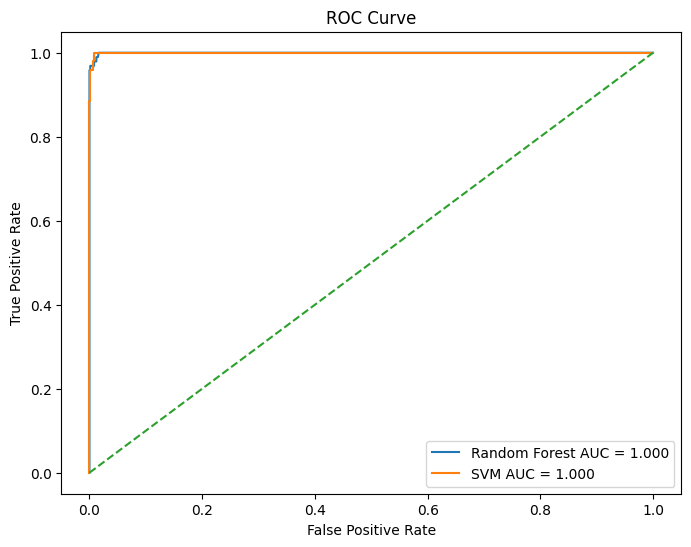

In [57]:
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {roc_auc_score(y_test, rf_probabilities):.3f}"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM AUC = {roc_auc_score(y_test, svm_probabilities):.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [58]:
feature_importance = pd.DataFrame({
    "Feature": classification_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,PurchaseFrequency,0.366699
1,Frequency,0.318760
3,TotalQuantity,0.128841
2,Monetary,0.127100
0,Recency,0.050869
4,AverageTransactionValue,0.007730


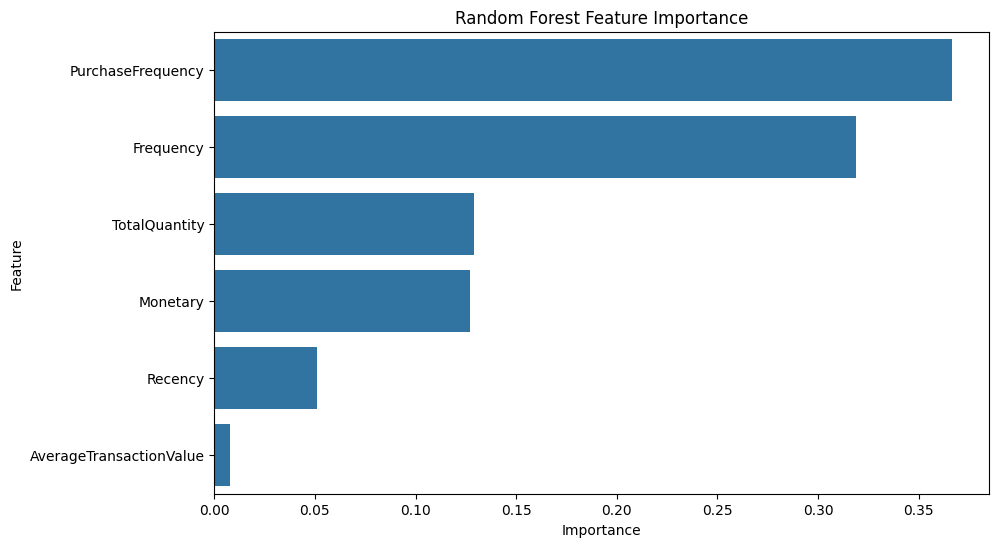

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [60]:
pca_3d = PCA(n_components=3)

X_pca_3d = pca_3d.fit_transform(X_scaled)

pca_3d_df = pd.DataFrame(
    X_pca_3d,
    columns=["PC1", "PC2", "PC3"]
)

pca_3d_df["Cluster"] = rfm["Cluster"].astype(str)

pca_3d_df["CustomerID"] = rfm["CustomerID"]

pca_3d_df.head()

,PC1,PC2,PC3,Cluster,CustomerID
0,3.119806,0.478411,-0.818435,3,12347
1,-1.181870,0.457484,0.276887,2,12348
2,0.022652,0.585451,-0.028063,1,12349
3,-1.464074,1.041405,0.910222,2,12350
4,1.689894,0.624225,0.049085,1,12352


In [61]:
fig = px.scatter_3d(
    pca_3d_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    hover_data=["CustomerID"],
    title="Interactive 3D Customer Segmentation"
)

fig.update_traces(
    marker=dict(size=5)
)

fig.show()

In [62]:
profile_for_display = cluster_profile.copy()

profile_for_display

,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency,CustomerCount
Cluster,,,,,,,
0,110.51,1.81,257.32,173.49,5.03,0.15,719
1,47.02,4.01,995.80,653.97,14.59,0.32,1430
2,153.19,1.35,216.69,135.91,17.02,0.11,1519
3,14.53,14.96,3318.79,2154.17,13.58,1.20,478


In [63]:
profile_normalized = cluster_profile[
    features_to_plot
].copy()

profile_normalized = (
    profile_normalized -
    profile_normalized.min()
) / (
    profile_normalized.max() -
    profile_normalized.min()
)

profile_normalized

,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency
Cluster,,,,,,
0,0.692197,0.033799,0.013098,0.018620,0.000000,0.036697
1,0.234314,0.195445,0.251156,0.256686,0.797331,0.192661
2,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
3,0.000000,1.000000,1.000000,1.000000,0.713094,1.000000


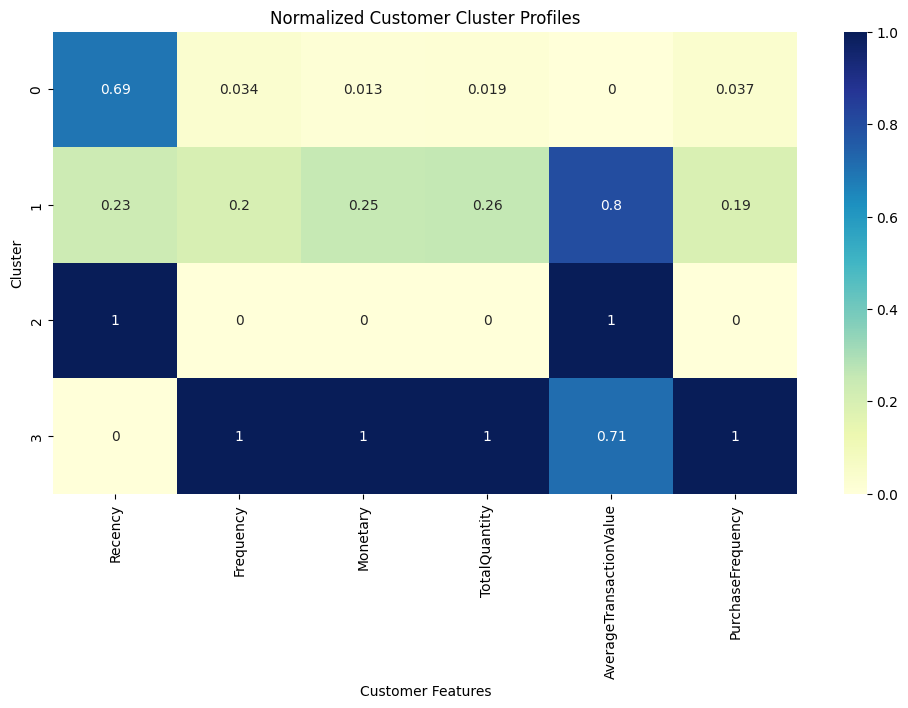

In [64]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    profile_normalized,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Normalized Customer Cluster Profiles")
plt.xlabel("Customer Features")
plt.ylabel("Cluster")

plt.show()

In [65]:
for cluster in sorted(rfm["Cluster"].unique()):

    data = cluster_profile.loc[cluster]

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster}")
    print("=" * 60)

    print(f"Customers: {int(data['CustomerCount'])}")
    print(f"Average Recency: {data['Recency']:.2f}")
    print(f"Average Frequency: {data['Frequency']:.2f}")
    print(f"Average Monetary Value: {data['Monetary']:.2f}")
    print(f"Average Quantity: {data['TotalQuantity']:.2f}")
    print(
        f"Average Transaction Value: "
        f"{data['AverageTransactionValue']:.2f}"
    )


CLUSTER 0
Customers: 719
Average Recency: 110.51
Average Frequency: 1.81
Average Monetary Value: 257.32
Average Quantity: 173.49
Average Transaction Value: 5.03

CLUSTER 1
Customers: 1430
Average Recency: 47.02
Average Frequency: 4.01
Average Monetary Value: 995.80
Average Quantity: 653.97
Average Transaction Value: 14.59

CLUSTER 2
Customers: 1519
Average Recency: 153.19
Average Frequency: 1.35
Average Monetary Value: 216.69
Average Quantity: 135.91
Average Transaction Value: 17.02

CLUSTER 3
Customers: 478
Average Recency: 14.53
Average Frequency: 14.96
Average Monetary Value: 3318.79
Average Quantity: 2154.17
Average Transaction Value: 13.58


CUSTOMER SEGMENT MARKETING RECOMMENDATIONS

1. HIGH-VALUE CUSTOMERS
   - Provide loyalty rewards.
   - Offer premium products.
   - Give early access to new products.
   - Provide personalized offers.
   - Encourage repeat purchases.

2. FREQUENT BUT LOWER-VALUE CUSTOMERS
   - Use cross-selling campaigns.
   - Recommend complementary products.
   - Provide bundle discounts.
   - Encourage larger basket sizes.

3. HIGH-RECENCY / LOW-FREQUENCY CUSTOMERS
   - Send personalized product recommendations.
   - Offer limited-time discounts.
   - Use email reminders.
   - Encourage a second purchase.

4. LOW-RECENCY CUSTOMERS
   - Run win-back campaigns.
   - Provide reactivation discounts.
   - Send personalized reminders.
   - Highlight new products and offers.

In [67]:
final_customer_data = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "TotalQuantity",
        "AverageTransactionValue",
        "PurchaseFrequency",
        "Cluster",
        "HighValue"
    ]
]

final_customer_data.head(10)

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageTransactionValue,PurchaseFrequency,Cluster,HighValue
0,12347,2,7,2783.37,1701,17.957226,0.563003,3,1
1,12348,249,3,90.20,140,15.033333,0.241287,2,0
2,12349,19,1,939.75,511,16.486842,0.080429,1,0
3,12350,310,1,294.40,196,18.400000,0.080429,2,0
4,12352,36,7,1130.94,500,17.135455,0.563003,1,0
5,12353,204,1,29.30,14,14.650000,0.080429,2,0
6,12354,232,1,642.13,355,16.464872,0.080429,2,0
7,12355,214,1,179.40,72,22.425000,0.080429,2,0
8,12356,246,2,491.06,386,19.642400,0.160858,2,0
9,12357,33,1,1289.35,1077,19.244030,0.080429,1,0


CONCLUSION

The Online Retail dataset was preprocessed by handling missing customer
identifiers, cancelled transactions, invalid quantities and prices, and
extreme outliers.

Customer-level features were created using Recency, Frequency, Monetary
Value, total quantity, average transaction value and purchase frequency.

K-Means clustering was applied to identify customer segments. The Elbow
Method was used to select the number of clusters and the Silhouette Score
was used to evaluate clustering quality.

Hierarchical clustering was also performed and compared with K-Means using
the Silhouette Score.

PCA was applied to reduce the customer feature space and visualize the
segments in two dimensions. An interactive 3D Plotly visualization was also
created.

The identified clusters were profiled according to their purchasing
characteristics. The cluster with the strongest monetary and frequency
characteristics was treated as the high-value customer segment.

Random Forest and SVM classification models were then trained to predict
whether a customer belongs to the high-value segment.

The models were evaluated using Accuracy, Precision, Recall, F1-Score,
ROC-AUC and Confusion Matrix. Random Forest feature importance was also
used to identify the customer features contributing to high-value
classification.

Finally, segment-specific marketing strategies were developed for
high-value, frequent, low-frequency and inactive customers.